In [1]:
import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (668665, 15)
Test shape: (286571, 14)


In [3]:
train.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13 

In [5]:
train["Will_Buy_EV"].value_counts()

,count
Will_Buy_EV,
No,551886
Yes,116779


In [6]:
train.isnull().sum()

,0
id,0
Age,0
Annual_Income_USD,0
Daily_Commute_km,0
Number_of_Cars_Owned,0
Charging_Stations_Near_Home,0
Charging_Stations_Near_Work,0
Environmental_Concern_Level,0
Gender,0
City_Type,0


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13 

In [8]:
categorical_cols = train.select_dtypes(include="object").columns

for col in categorical_cols:
    print("\n", col)
    print(train[col].value_counts())


 Gender
Gender
Male      367954
Female    295427
Other       5284
Name: count, dtype: int64

 City_Type
City_Type
Urban       289305
Suburban    255377
Rural       123983
Name: count, dtype: int64

 Current_Car_Type
Current_Car_Type
Sedan        303459
SUV          246545
Hatchback     79438
Truck         39223
Name: count, dtype: int64

 Home_Charging_Possible
Home_Charging_Possible
Yes    462677
No     205988
Name: count, dtype: int64

 Subsidy_Available
Subsidy_Available
Yes    419909
No     248756
Name: count, dtype: int64

 Range_Anxiety_Level
Range_Anxiety_Level
Low       603972
Medium     62499
High        2194
Name: count, dtype: int64

 Will_Buy_EV
Will_Buy_EV
No     551886
Yes    116779
Name: count, dtype: int64


In [9]:
pd.crosstab(
    train["Home_Charging_Possible"],
    train["Will_Buy_EV"],
    normalize="index"
) * 100

Will_Buy_EV,No,Yes
Home_Charging_Possible,,
No,87.291493,12.708507
Yes,80.418089,19.581911


In [10]:
pd.crosstab(
    train["Subsidy_Available"],
    train["Will_Buy_EV"],
    normalize="index"
) * 100

Will_Buy_EV,No,Yes
Subsidy_Available,,
No,99.424335,0.575665
Yes,72.530477,27.469523


In [11]:
pd.crosstab(
    train["Range_Anxiety_Level"],
    train["Will_Buy_EV"],
    normalize="index"
) * 100

Will_Buy_EV,No,Yes
Range_Anxiety_Level,,
High,99.863263,0.136737
Low,81.097303,18.902697
Medium,95.825533,4.174467


In [12]:
train.groupby("Will_Buy_EV")[
    ["Age", "Annual_Income_USD", "Daily_Commute_km",
     "Number_of_Cars_Owned",
     "Charging_Stations_Near_Home",
     "Charging_Stations_Near_Work",
     "Environmental_Concern_Level"]
].mean()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
Will_Buy_EV,,,,,,,
No,47.083293,81794.588556,32.553478,1.711319,4.989947,7.205490,2.630395
Yes,46.830654,98827.302948,30.290714,1.718802,4.820807,7.038432,4.377268


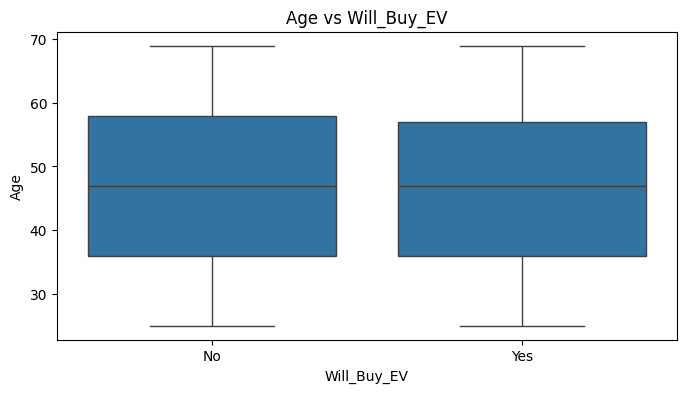

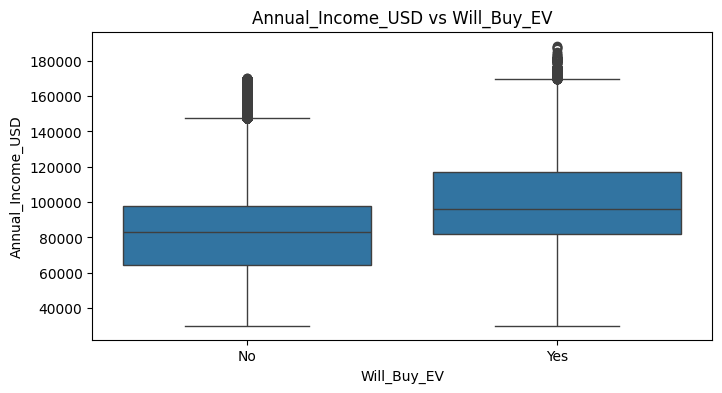

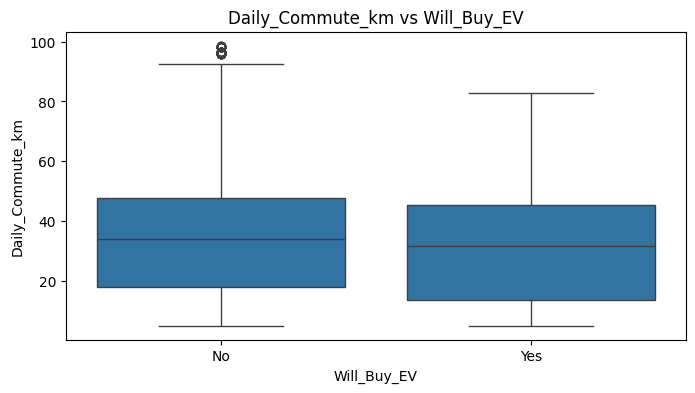

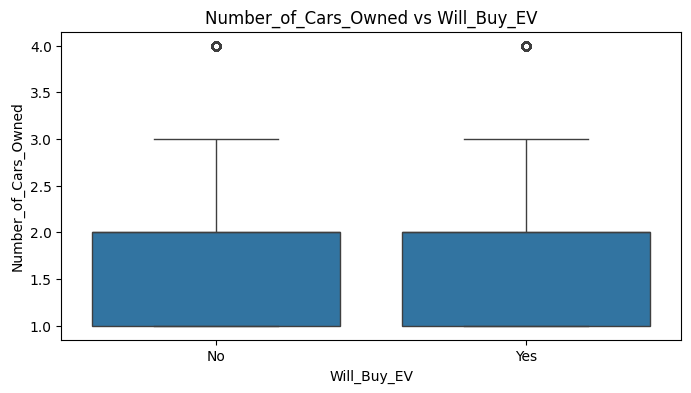

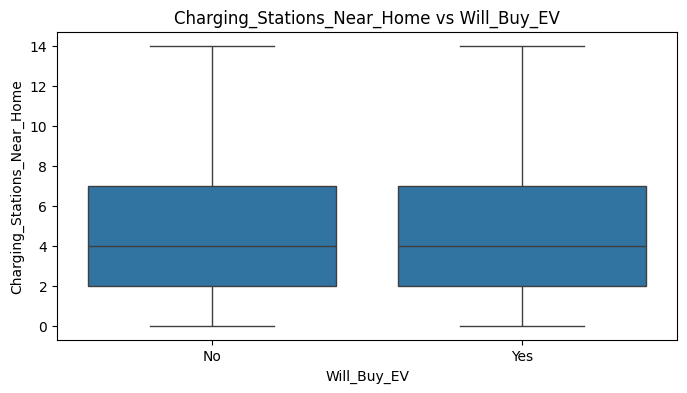

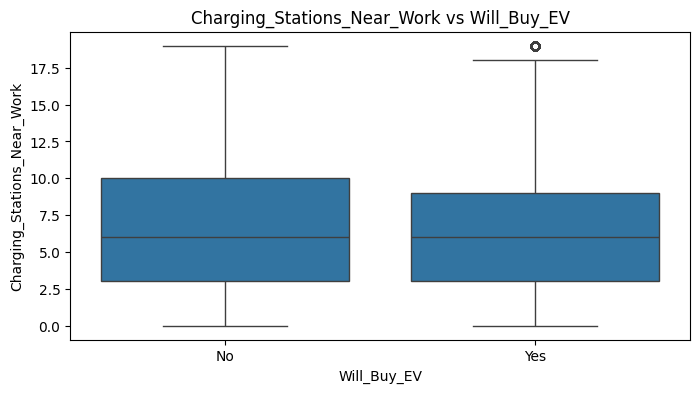

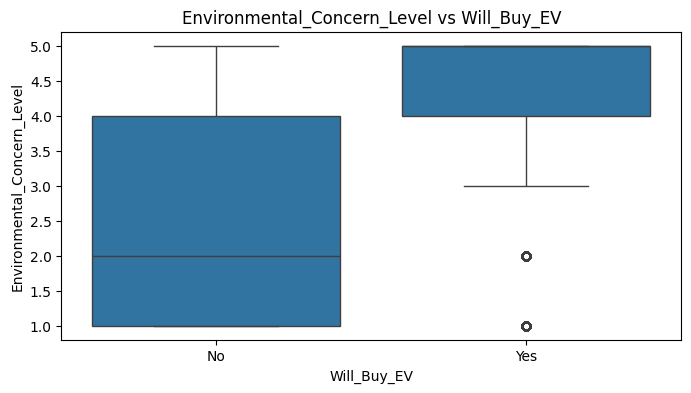

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = [
    "Age",
    "Annual_Income_USD",
    "Daily_Commute_km",
    "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "Environmental_Concern_Level"
]

for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=train, x="Will_Buy_EV", y=col)
    plt.title(f"{col} vs Will_Buy_EV")
    plt.show()

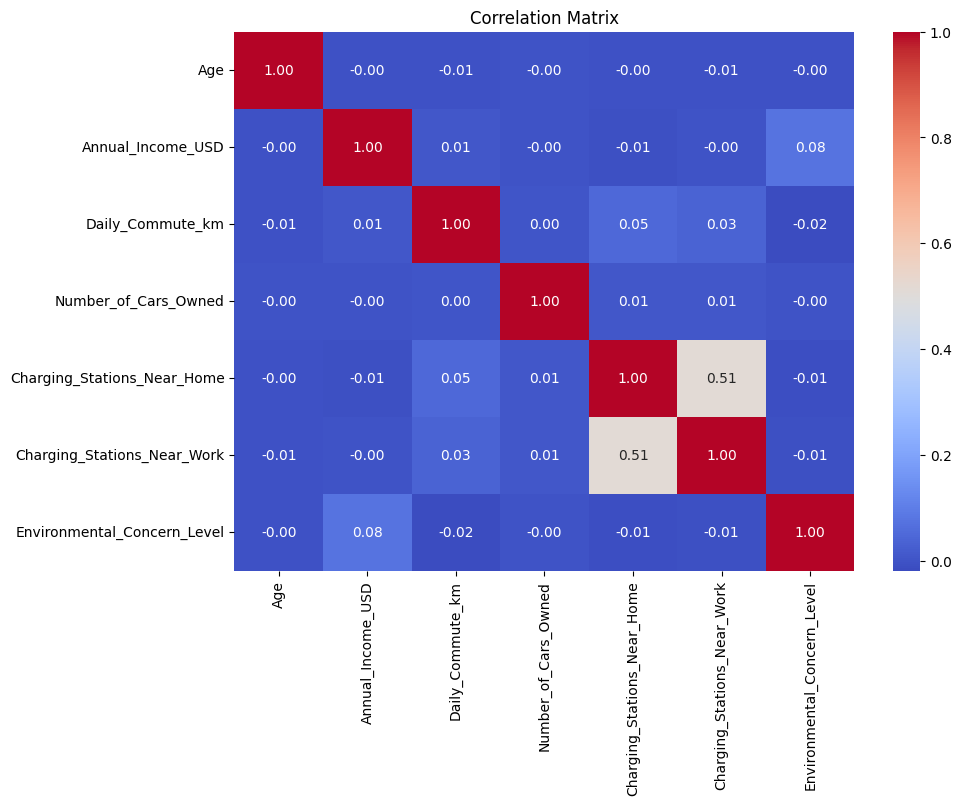

In [14]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    train[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [15]:
X = train.drop(columns=["Will_Buy_EV"])
y = train["Will_Buy_EV"]

In [16]:
X = X.drop(columns=["id"])
test_features = test.drop(columns=["id"])

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [18]:
train["Will_Buy_EV"] = train["Will_Buy_EV"].map({
    "No": 0,
    "Yes": 1
})

X = train.drop(columns=["Will_Buy_EV", "id"])
y = train["Will_Buy_EV"]

test_features = test.drop(columns=["id"])

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("Test:", test_features.shape)

X_train: (534932, 13)
X_valid: (133733, 13)
Test: (286571, 13)


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Numerical columns
numerical_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

# Categorical columns
categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns

print("Numerical columns:")
print(list(numerical_cols))

print("\nCategorical columns:")
print(list(categorical_cols))

Numerical columns:
['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']

Categorical columns:
['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_valid_encoded = preprocessor.transform(X_valid)
test_encoded = preprocessor.transform(test_features)

print("X_train encoded shape:", X_train_encoded.shape)
print("X_valid encoded shape:", X_valid_encoded.shape)
print("Test encoded shape:", test_encoded.shape)

X_train encoded shape: (534932, 24)
X_valid encoded shape: (133733, 24)
Test encoded shape: (286571, 24)


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_lr.fit(X_train_encoded, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [22]:
y_valid_prob = model_lr.predict_proba(X_valid_encoded)[:, 1]

roc_auc = roc_auc_score(y_valid, y_valid_prob)

print("Validation ROC-AUC:", roc_auc)

Validation ROC-AUC: 0.9085092064461885


In [24]:
model_lr.predict_proba(X_valid_encoded)

array([[0.96947084, 0.03052916],
       [0.97227697, 0.02772303],
       [0.73818646, 0.26181354],
       ...,
       [0.17581524, 0.82418476],
       [0.95017782, 0.04982218],
       [0.74769892, 0.25230108]])

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Create model
model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train model
model_lr.fit(X_train_encoded, y_train)

# Predict probability of Yes
y_valid_prob = model_lr.predict_proba(X_valid_encoded)[:, 1]

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_valid, y_valid_prob)

print("Validation ROC-AUC:", roc_auc)

Validation ROC-AUC: 0.9085092064461885


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [26]:
!pip install xgboost -q

In [27]:
from xgboost import XGBClassifier

In [28]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_encoded,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)

In [29]:
y_valid_prob_xgb = xgb_model.predict_proba(X_valid_encoded)[:, 1]

roc_auc_xgb = roc_auc_score(
    y_valid,
    y_valid_prob_xgb
)

print("XGBoost Validation ROC-AUC:", roc_auc_xgb)

XGBoost Validation ROC-AUC: 0.9416721584139047


In [30]:
import pandas as pd

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
19,cat__Subsidy_Available_No,0.440220
20,cat__Subsidy_Available_Yes,0.291265
6,num__Environmental_Concern_Level,0.199517
22,cat__Range_Anxiety_Level_Low,0.027011
1,num__Annual_Income_USD,0.009404
23,cat__Range_Anxiety_Level_Medium,0.007191
21,cat__Range_Anxiety_Level_High,0.002901
17,cat__Home_Charging_Possible_No,0.002627
18,cat__Home_Charging_Possible_Yes,0.002383
2,num__Daily_Commute_km,0.001763


In [31]:
xgb_model_1 = XGBClassifier(
    n_estimators=700,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_model_1.fit(X_train_encoded, y_train)

pred_1 = xgb_model_1.predict_proba(X_valid_encoded)[:, 1]

auc_1 = roc_auc_score(y_valid, pred_1)

print("Model 1 ROC-AUC:", auc_1)

Model 1 ROC-AUC: 0.9417554502671077


In [32]:
xgb_model_2 = XGBClassifier(
    n_estimators=700,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_model_2.fit(X_train_encoded, y_train)

pred_2 = xgb_model_2.predict_proba(X_valid_encoded)[:, 1]

auc_2 = roc_auc_score(y_valid, pred_2)

print("Model 2 ROC-AUC:", auc_2)

Model 2 ROC-AUC: 0.9415513266825263


In [33]:
xgb_model_3 = XGBClassifier(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_model_3.fit(X_train_encoded, y_train)

pred_3 = xgb_model_3.predict_proba(X_valid_encoded)[:, 1]

auc_3 = roc_auc_score(y_valid, pred_3)

print("Model 3 ROC-AUC:", auc_3)

Model 3 ROC-AUC: 0.9408532387131374


In [34]:
# Test data वर EV खरेदीची probability predict करणे
test_pred = xgb_model_1.predict_proba(test_encoded)[:, 1]

print(test_pred[:10])

[1.2344790e-02 1.7128140e-02 5.3162556e-03 3.3105796e-03 2.1278873e-02
 4.4307918e-03 3.8105261e-01 2.7075730e-04 6.7016780e-01 5.2715833e-03]


In [35]:
submission = pd.DataFrame({
    "id": test["id"],
    "Will_Buy_EV": test_pred
})

submission.head()

,id,Will_Buy_EV
0,668665,0.012345
1,668666,0.017128
2,668667,0.005316
3,668668,0.003311
4,668669,0.021279


In [36]:
submission.to_csv("/content/submission.csv", index=False)

print("submission.csv created successfully!")

submission.csv created successfully!


In [37]:
submission.shape

(286571, 2)